# Support Vector Machine

This notebook trains and evaluates a support vector machine classifier for predicting whether a mushroom is poisonous or edible

## Set Up

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
%matplotlib inline
import seaborn as sns
from sklearn.model_selection import train_test_split    
from sklearn.svm import SVC

pd.set_option('display.max_columns', None)


## Exploratory Data Analysis

Load Clean Data

In [2]:
raw_data = pd.read_csv('../Data/clean_data.csv')
raw_data

,class,cap-diameter,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-height,stem-width,stem-color,has-ring,ring-type,habitat,season
0,p,1.619462,x,g,o,f,e,c,w,3.076705,0.492293,w,t,g,d,w
1,p,1.873982,x,g,o,f,e,c,w,3.385311,0.601900,w,t,g,d,u
2,p,1.393432,x,g,o,f,e,c,w,3.328931,0.557061,w,t,g,d,w
3,p,1.412426,f,h,e,f,e,c,w,2.726555,0.381690,w,t,p,d,w
4,p,1.501699,x,h,o,f,e,c,w,2.952075,0.503254,w,t,p,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,p,-1.054903,s,s,y,f,f,f,f,-0.786809,-0.590822,y,f,f,d,a
61065,p,-1.037808,f,s,y,f,f,f,f,-1.009362,-0.669539,y,f,f,d,a
61066,p,-1.037808,s,s,y,f,f,f,f,-0.807581,-0.575875,y,f,f,d,u
61067,p,-1.043506,f,s,y,f,f,f,f,-0.896602,-0.668543,y,f,f,d,u


In [5]:
raw_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 61069 entries, 0 to 61068
Data columns (total 16 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   class                 61069 non-null  object 
 1   cap-diameter          61069 non-null  float64
 2   cap-shape             61069 non-null  object 
 3   cap-surface           61069 non-null  object 
 4   cap-color             61069 non-null  object 
 5   does-bruise-or-bleed  61069 non-null  object 
 6   gill-attachment       61069 non-null  object 
 7   gill-spacing          61069 non-null  object 
 8   gill-color            61069 non-null  object 
 9   stem-height           61069 non-null  float64
 10  stem-width            61069 non-null  float64
 11  stem-color            61069 non-null  object 
 12  has-ring              61069 non-null  object 
 13  ring-type             61069 non-null  object 
 14  habitat               61069 non-null  object 
 15  season             

In [6]:
raw_data.describe()

,cap-diameter,stem-height,stem-width
count,6.106900e+04,6.106900e+04,6.106900e+04
mean,6.701806e-17,2.233935e-16,-1.265897e-16
std,1.000008e+00,1.000008e+00,1.000008e+00
min,-1.206855e+00,-1.952985e+00,-1.210598e+00
25%,-6.180393e-01,-5.761259e-01,-6.914605e-01
50%,-1.659805e-01,-1.874007e-01,-1.952406e-01
75%,3.430605e-01,3.437583e-01,4.404789e-01
max,1.056187e+01,8.112329e+00,9.143259e+00


The data was standardized in the DataCleaning notebook.

In [11]:
#Check for class imbalance
raw_data['class'].value_counts()

class
p    33888
e    27181
Name: count, dtype: int64

array([[<Axes: title={'center': 'cap-diameter'}>,
        <Axes: title={'center': 'stem-height'}>],
       [<Axes: title={'center': 'stem-width'}>, <Axes: >]], dtype=object)

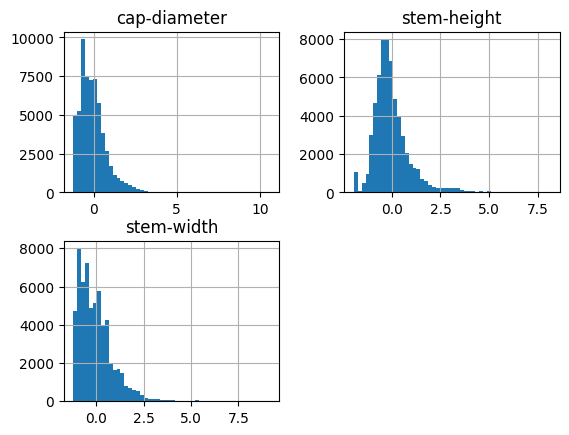

In [8]:
raw_data.hist(bins=50)

Need to transform to have a better bell shape

Now, let's create a test set. 

In [12]:
from sklearn.model_selection import train_test_split

train_set, test_set = train_test_split(raw_data, test_size=0.2, random_state=42)

Check for correlation of numeric variables

In [22]:
# chi-square test to check independence between categorical variables
import scipy.stats as stats
from scipy.stats import chi2_contingency

# contingency table 
table = pd.crosstab(raw_data['class'], raw_data['cap-color'])

chi2, p, dof, ex = chi2_contingency(table)
print(f"{p:.10e}") # p-value
# If p-value < 0.05, we reject the null hypothesis and conclude that there is a significant association between the variables.
chi2


0.0000000000e+00


3541.079818275377

In [25]:
table

cap-color,b,e,g,k,l,n,o,p,r,u,w,y
class,,,,,,,,,,,,
e,974,880,2297,501,452,12407,1071,449,198,611,3750,3591
p,256,3155,2123,778,376,11811,2585,1254,1584,1098,3916,4952


In [ ]:
from scipy.stats import chi2_contingency


# function to perform chi-square test
def test_independence(data, var1, var2):
    table = pd.crosstab(data[var1], data[var2])
    chi2, p, dof, ex = chi2_contingency(table)
    print(f"{table}")
    return p

In [32]:
# test independece between 'class' and other categorical variables
categorical_vars = raw_data.select_dtypes(include=['object']).columns.tolist()
categorical_vars.remove('class')
for var in categorical_vars:
    p_value = test_independence(raw_data, 'class', var)
    print(f"P-value for independence between 'class' and '{var}': {p_value:.10e}")
    if p_value < 0.05:
        print(f"Reject null hypothesis: 'class' and '{var}' are dependent.\n")
    else:
        print(f"Fail to reject null hypothesis: 'class' and '{var}' are independent.\n")



cap-shape     b     c     f     o     p     s      x
class                                               
e          1258   774  6502   825  1567  3295  12960
p          4436  1041  6902  2635  1031  3869  13974
P-value for independence between 'class' and 'cap-shape': 0.0000000000e+00
Reject null hypothesis: 'class' and 'cap-shape' are dependent.


cap-surface     d     e     g     h     i     k     l     s     t     w     y
class                                                                        
e            2200  2226  2008  3478   385   231  1366  5744  3806  1216  4521
p            2961  1532  3907  3206  2101  2670  1374  4052  7042  1567  3476
P-value for independence between 'class' and 'cap-surface': 0.0000000000e+00
Reject null hypothesis: 'class' and 'cap-surface' are dependent.


cap-color    b     e     g    k    l      n     o     p     r     u     w  \
class                                                                       
e          974   880  2297  501  452 

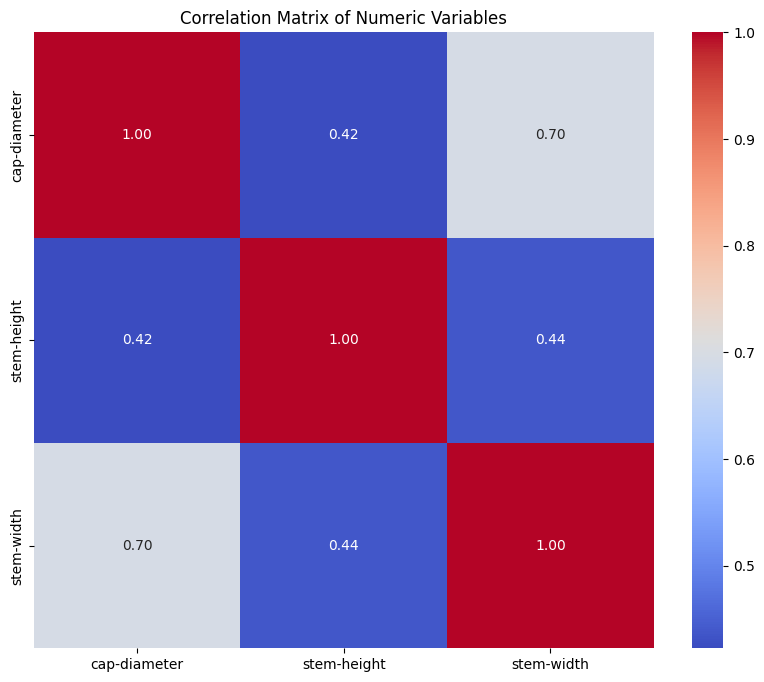

In [33]:
#Check for correlation of numeric variables
numeric_vars = raw_data.select_dtypes(include=[np.number]).columns.tolist()
correlation_matrix = raw_data[numeric_vars].corr()
plt.figure(figsize=(10, 8))
sns.heatmap(correlation_matrix, annot=True, cmap='coolwarm', fmt=".2f")
plt.title("Correlation Matrix of Numeric Variables")
plt.show()

In [47]:
# use l1 normalization on the numeric data
from sklearn.preprocessing import Normalizer
scaler = Normalizer(norm='l1')
numeric_data = raw_data.select_dtypes(include=[np.number])

# transform the numeric data
scaled_numeric_data = scaler.fit_transform(numeric_data)
scaled_numeric_df = pd.DataFrame(scaled_numeric_data, columns=numeric_data.columns)
scaled_numeric_df.describe()

# combine normalized numeric data with categorical data
categorical_data = raw_data.select_dtypes(include=['object']).reset_index(drop=True)
normalized_data = pd.concat([scaled_numeric_df, categorical_data], axis=1)
normalized_data.describe()



,cap-diameter,stem-height,stem-width
count,61069.000000,61069.000000,61069.000000
mean,-0.055402,-0.056587,-0.060957
std,0.333808,0.402070,0.390392
min,-0.976512,-0.987554,-0.992083
25%,-0.344921,-0.347397,-0.386375
50%,-0.150207,-0.143383,-0.199298
75%,0.238631,0.236063,0.277598
max,0.985443,0.996897,0.994495


One hot encode categorical variables


In [ ]:
#=========NOTE===============

# Use column transformer for all preprocessing (after chi squared test)

# initalized cat variables 

# intialize numeric variables 

# normalize numeric variables 

# one hot encode numeric 

In [51]:
normalized_data

,cap-diameter,stem-height,stem-width,class,cap-shape,cap-surface,cap-color,does-bruise-or-bleed,gill-attachment,gill-spacing,gill-color,stem-color,has-ring,ring-type,habitat,season
0,0.312128,0.592990,0.094882,p,x,g,o,f,e,c,w,w,t,g,d,w
1,0.319727,0.577581,0.102692,p,x,g,o,f,e,c,w,w,t,g,d,u
2,0.263936,0.630548,0.105515,p,x,g,o,f,e,c,w,w,t,g,d,w
3,0.312437,0.603131,0.084432,p,f,h,e,f,e,c,w,w,t,p,d,w
4,0.302943,0.595533,0.101523,p,x,h,o,f,e,c,w,w,t,p,d,w
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,-0.433664,-0.323453,-0.242883,p,s,s,y,f,f,f,f,y,f,f,d,a
61065,-0.382009,-0.371538,-0.246452,p,f,s,y,f,f,f,f,y,f,f,d,a
61066,-0.428622,-0.333537,-0.237841,p,s,s,y,f,f,f,f,y,f,f,d,u
61067,-0.400018,-0.343703,-0.256279,p,f,s,y,f,f,f,f,y,f,f,d,u


In [53]:
from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import LabelEncoder

encoder = OneHotEncoder(sparse_output = False)

# categorical columns not including class
categorical_features = raw_data.select_dtypes(include=['object']).drop(columns=['class'])

# fit and transform the all categorical columns
encoded_features = encoder.fit_transform(raw_data[categorical_features.columns])

# encode target variable
le = LabelEncoder()
raw_data['class'] = le.fit_transform(raw_data['class'])

# combine encoded features with normalized numeric features
final_data = pd.concat([scaled_numeric_df, pd.DataFrame(encoded_features, columns=encoder.get_feature_names_out(categorical_features.columns)), raw_data['class'].reset_index(drop=True)], axis=1)
final_data

,cap-diameter,stem-height,stem-width,cap-shape_b,cap-shape_c,cap-shape_f,cap-shape_o,cap-shape_p,cap-shape_s,cap-shape_x,cap-surface_d,cap-surface_e,cap-surface_g,cap-surface_h,cap-surface_i,cap-surface_k,cap-surface_l,cap-surface_s,cap-surface_t,cap-surface_w,cap-surface_y,cap-color_b,cap-color_e,cap-color_g,cap-color_k,cap-color_l,cap-color_n,cap-color_o,cap-color_p,cap-color_r,cap-color_u,cap-color_w,cap-color_y,does-bruise-or-bleed_f,does-bruise-or-bleed_t,gill-attachment_a,gill-attachment_d,gill-attachment_e,gill-attachment_f,gill-attachment_p,gill-attachment_s,gill-attachment_x,gill-spacing_c,gill-spacing_d,gill-spacing_f,gill-color_b,gill-color_e,gill-color_f,gill-color_g,gill-color_k,gill-color_n,gill-color_o,gill-color_p,gill-color_r,gill-color_u,gill-color_w,gill-color_y,stem-color_b,stem-color_e,stem-color_f,stem-color_g,stem-color_k,stem-color_l,stem-color_n,stem-color_o,stem-color_p,stem-color_r,stem-color_u,stem-color_w,stem-color_y,has-ring_f,has-ring_t,ring-type_e,ring-type_f,ring-type_g,ring-type_l,ring-type_m,ring-type_p,ring-type_r,ring-type_z,habitat_d,habitat_g,habitat_h,habitat_l,habitat_m,habitat_p,habitat_u,habitat_w,season_a,season_s,season_u,season_w,class
0,0.312128,0.592990,0.094882,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
1,0.319727,0.577581,0.102692,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,1
2,0.263936,0.630548,0.105515,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
3,0.312437,0.603131,0.084432,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
4,0.302943,0.595533,0.101523,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
61064,-0.433664,-0.323453,-0.242883,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,1.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.0,0.0,0.0,0.0,1
61065,-0.382009,-0.371538,-0.246452,0.0,0.0,1.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0,1.

Model training

In [54]:
target = 'class'

# features 
X = final_data.drop(columns=target)

# Class (poison or edible)
y = final_data[target]

In [55]:
# train test split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=.2, random_state=42)

In [56]:
# build svm with hinge loss
from sklearn.svm import LinearSVC
svm = LinearSVC(random_state=42, loss='hinge', fit_intercept = False)

svm.fit(X_train, y_train)

/Users/gerardogutierrez/Library/Python/3.9/lib/python/site-packages/sklearn/svm/_base.py:1249: ConvergenceWarning: Liblinear failed to converge, increase the number of iterations.
  warnings.warn(


LinearSVC(fit_intercept=False, loss='hinge', random_state=42)

Evaluate model

In [59]:
y_pred_score = svm.decision_function(X_test)
y_pred_score

array([-1.22845518e+00,  2.22969538e+00, -4.21006213e-02, ...,
        5.77239031e-01, -9.22543914e-04, -1.09662892e+00])

In [60]:
y_pred_class = svm.predict(X_test)
y_pred_class

array([0, 1, 0, ..., 1, 0, 0])

In [61]:
from sklearn.metrics import roc_auc_score
roc_auc_svm = roc_auc_score(y_test, y_pred_score)
print(f"SVM ROC AUC Score: {roc_auc_svm:.4f}")

SVM ROC AUC Score: 0.8606


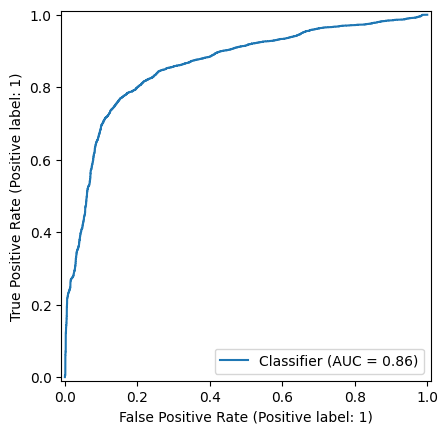

In [62]:
# plot roc curve
from sklearn.metrics import RocCurveDisplay
RocCurveDisplay.from_predictions(y_test, y_pred_score)